# AI-Driven Grid Outage Analytics Platform - Phase 3 Exploratory Data Analysis

This notebook performs a deep-dive Exploratory Data Analysis (EDA) on the Terna grid dataset and supplementary grid operation data. We will analyze outage frequencies, downtime durations, reasons, temporal trends, demand/forecast relationships, generation by source, cross-border exchanges, and renewable connection requests.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

processed_dir = r"C:\Users\kk928\.gemini\antigravity\scratch\terna-ai-platform\data\processed"
images_dir = r"C:\Users\kk928\.gemini\antigravity\scratch\terna-ai-platform\reports\images"
os.makedirs(images_dir, exist_ok=True)

# Load datasets
outages = pd.read_csv(os.path.join(processed_dir, "merged_outages.csv"))
outages["start_datetime"] = pd.to_datetime(outages["start_datetime"])
outages["stop_datetime"] = pd.to_datetime(outages["stop_datetime"])

demand = pd.read_csv(os.path.join(processed_dir, "demand_and_forecast.csv"))
demand["datetime"] = pd.to_datetime(demand["datetime"])

generation = pd.read_csv(os.path.join(processed_dir, "generation_by_source.csv"))
generation["datetime"] = pd.to_datetime(generation["datetime"])

imports = pd.read_csv(os.path.join(processed_dir, "imports_exports.csv"))
imports["datetime"] = pd.to_datetime(imports["datetime"])

avail_capacity = pd.read_csv(os.path.join(processed_dir, "available_capacity.csv"))
avail_capacity["datetime"] = pd.to_datetime(avail_capacity["datetime"])

forecast_capacity = pd.read_csv(os.path.join(processed_dir, "forecast_capacity.csv"))
forecast_capacity["datetime"] = pd.to_datetime(forecast_capacity["datetime"])

regional_consumption = pd.read_csv(os.path.join(processed_dir, "regional_consumption_by_sector.csv"))
requests = pd.read_csv(os.path.join(processed_dir, "renewable_connection_requests.csv"))

print("All datasets loaded successfully!")
print(f"Outages: {outages.shape}, Demand: {demand.shape}, Generation: {generation.shape}")


All datasets loaded successfully!
Outages: (17846, 11), Demand: (23040, 4), Generation: (17280, 3)


## 1. Outage Frequencies by Asset Type & Voltage Level

We will analyze which assets and voltage levels are most frequently put under maintenance.
*   **Asset Type Codes**: `LIN` = Line, `STL` = Bay (Stallo), `SBA` = Busbars (Sbarre), `ATR` = Autotransformer, `TRF` = Transformer, `RIF` = Capacitor/Reactor.


C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\3926902539.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=outages, x="asset_type", order=outages["asset_type"].value_counts().index, ax=axes[0], palette="viridis")
C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\3926902539.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=outages, x="voltage_kv", order=outages["voltage_kv"].value_counts().index, ax=axes[1], palette="magma")


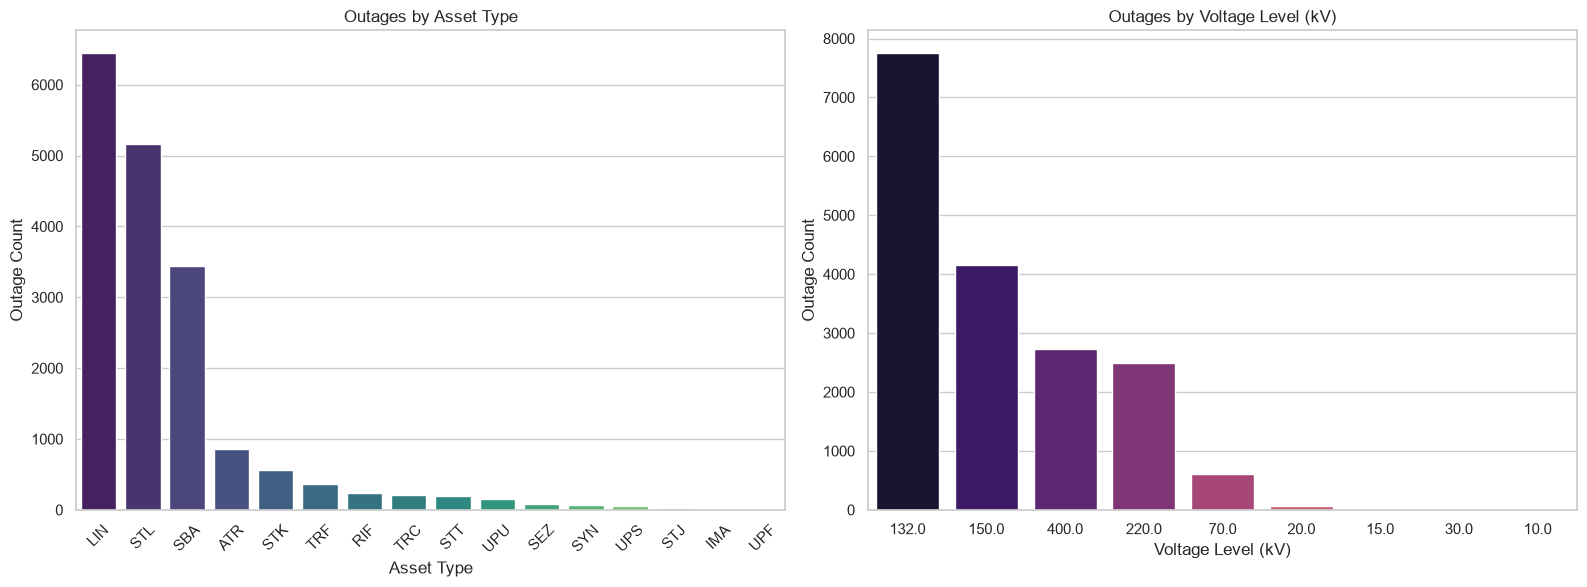

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count by Asset Type
sns.countplot(data=outages, x="asset_type", order=outages["asset_type"].value_counts().index, ax=axes[0], palette="viridis")
axes[0].set_title("Outages by Asset Type")
axes[0].set_xlabel("Asset Type")
axes[0].set_ylabel("Outage Count")
axes[0].tick_params(axis='x', rotation=45)

# Count by Voltage Level
sns.countplot(data=outages, x="voltage_kv", order=outages["voltage_kv"].value_counts().index, ax=axes[1], palette="magma")
axes[1].set_title("Outages by Voltage Level (kV)")
axes[1].set_xlabel("Voltage Level (kV)")
axes[1].set_ylabel("Outage Count")

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "01_outages_by_asset_type_voltage.png"), dpi=150, bbox_inches="tight")
plt.show()


## 2. Average Outage Durations

We will analyze the average outage duration by asset type and voltage level to identify which maintenance operations take the longest.


C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\3176838255.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_dur_asset, x="asset_type", y="duration_hours", ax=axes[0], palette="viridis")
C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\3176838255.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_dur_kv, x="voltage_kv", y="duration_hours", ax=axes[1], palette="magma", order=avg_dur_kv["voltage_kv"])


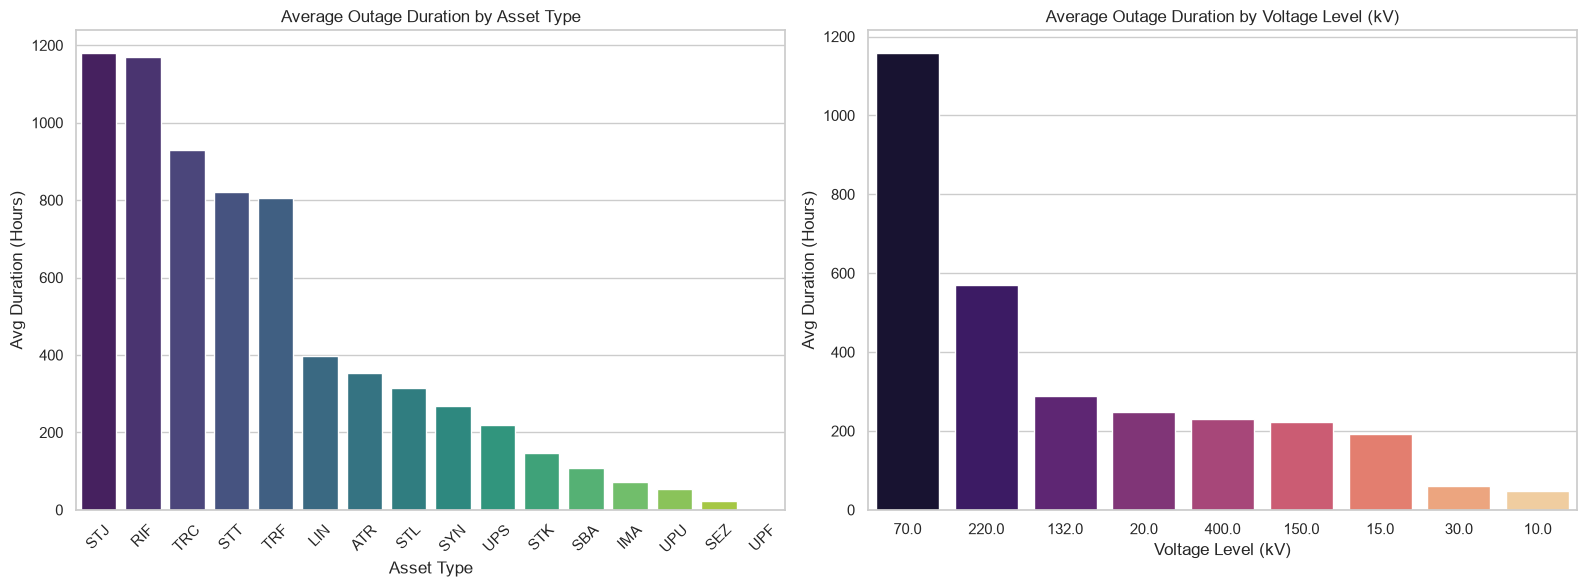

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg duration by asset type
avg_dur_asset = outages.groupby("asset_type")["duration_hours"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_dur_asset, x="asset_type", y="duration_hours", ax=axes[0], palette="viridis")
axes[0].set_title("Average Outage Duration by Asset Type")
axes[0].set_xlabel("Asset Type")
axes[0].set_ylabel("Avg Duration (Hours)")
axes[0].tick_params(axis='x', rotation=45)

# Avg duration by voltage level
avg_dur_kv = outages.groupby("voltage_kv")["duration_hours"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_dur_kv, x="voltage_kv", y="duration_hours", ax=axes[1], palette="magma", order=avg_dur_kv["voltage_kv"])
axes[1].set_title("Average Outage Duration by Voltage Level (kV)")
axes[1].set_xlabel("Voltage Level (kV)")
axes[1].set_ylabel("Avg Duration (Hours)")

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "02_outage_duration_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


## 3. Most Common Maintenance Reasons


C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\761112595.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_reasons, y="reason", x="count", palette="plasma")


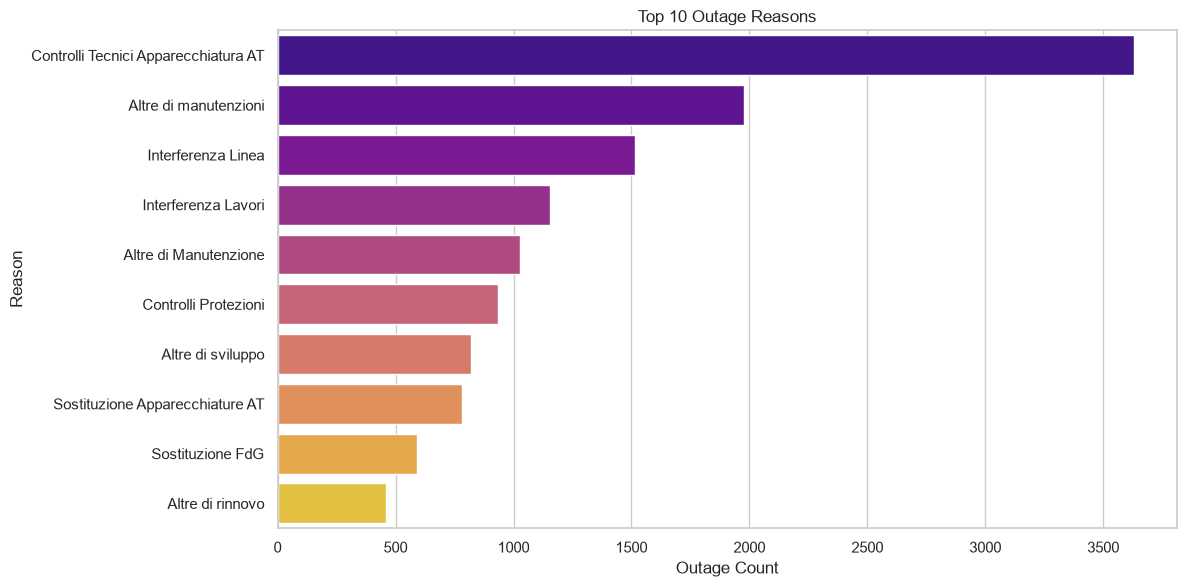

In [4]:
top_reasons = outages["reason"].value_counts().head(10).reset_index()

sns.barplot(data=top_reasons, y="reason", x="count", palette="plasma")
plt.title("Top 10 Outage Reasons")
plt.xlabel("Outage Count")
plt.ylabel("Reason")

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "03_outage_reasons.png"), dpi=150, bbox_inches="tight")
plt.show()


## 4. Weekly and Monthly Outage Trends


C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\3419751037.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_counts, x="month", y="count", ax=axes[0], palette="Blues_r")


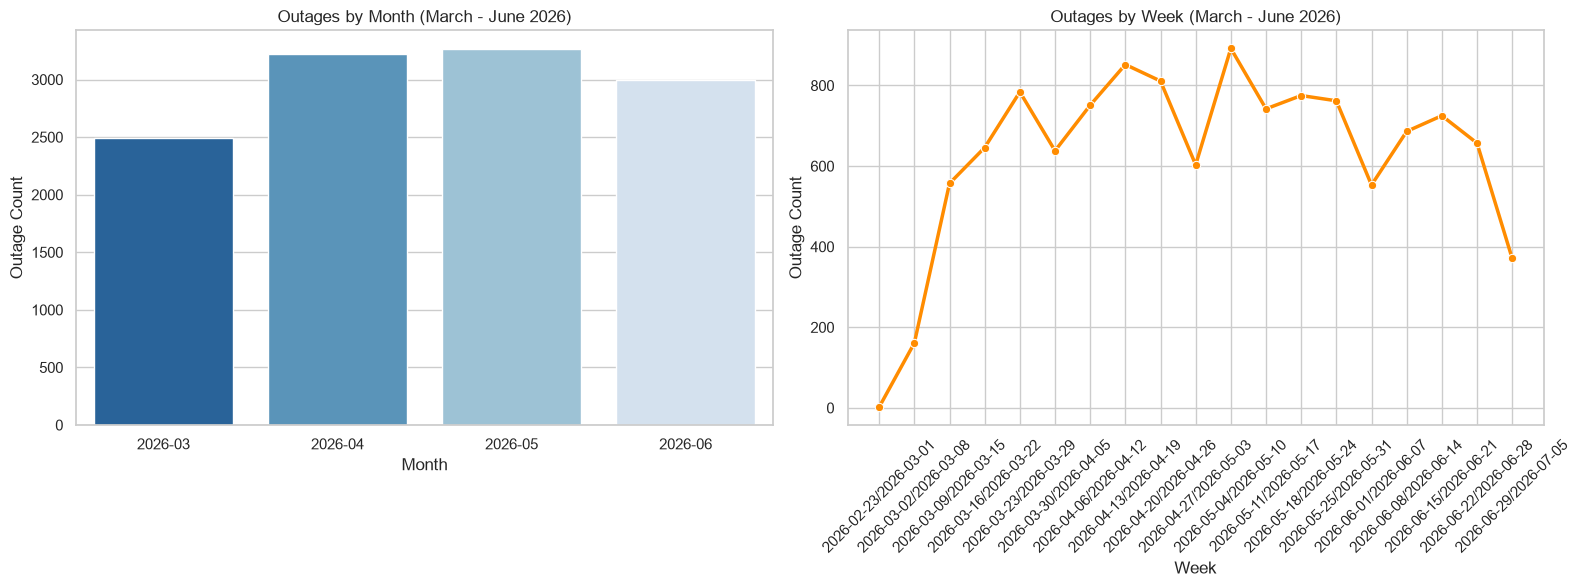

In [5]:
outages["month"] = outages["start_datetime"].dt.to_period("M")
outages["week"] = outages["start_datetime"].dt.to_period("W")

# Filter for March-June 2026 data
outages_2026 = outages[(outages["start_datetime"] >= "2026-03-01") & (outages["start_datetime"] <= "2026-06-30")]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly trends
monthly_counts = outages_2026.groupby("month").size().reset_index(name="count")
monthly_counts["month"] = monthly_counts["month"].astype(str)
sns.barplot(data=monthly_counts, x="month", y="count", ax=axes[0], palette="Blues_r")
axes[0].set_title("Outages by Month (March - June 2026)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Outage Count")

# Weekly trends
weekly_counts = outages_2026.groupby("week").size().reset_index(name="count")
weekly_counts["week"] = weekly_counts["week"].astype(str)
sns.lineplot(data=weekly_counts, x="week", y="count", marker="o", ax=axes[1], color="darkorange", linewidth=2.5)
axes[1].set_title("Outages by Week (March - June 2026)")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Outage Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "04_temporal_trends.png"), dpi=150, bbox_inches="tight")
plt.show()


## 5. Top 10 Individual Assets by Total Downtime


C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\3088579817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_assets, y="assets_concerned", x="duration_hours", palette="flare")


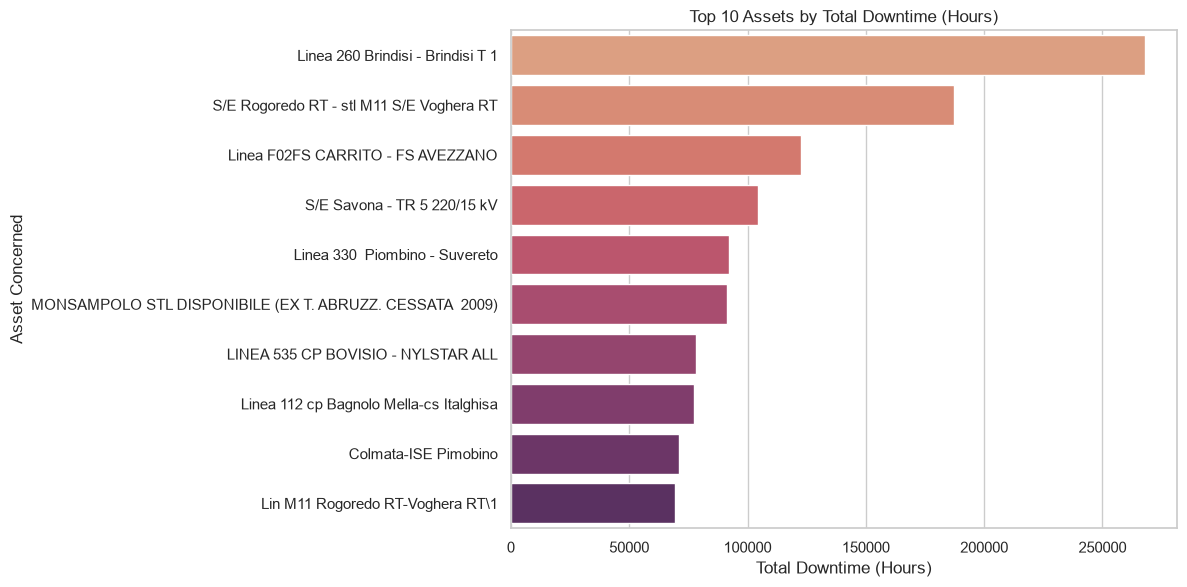

In [6]:
top_assets = outages.groupby("assets_concerned")["duration_hours"].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_assets, y="assets_concerned", x="duration_hours", palette="flare")
plt.title("Top 10 Assets by Total Downtime (Hours)")
plt.xlabel("Total Downtime (Hours)")
plt.ylabel("Asset Concerned")

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "05_top_downtime_assets.png"), dpi=150, bbox_inches="tight")
plt.show()


## 6. Electricity Demand and Forecast by Bidding Zone

We will analyze the load patterns and the forecasting error across Italy's bidding zones (North, South, Sicily, Sardinia, etc.).


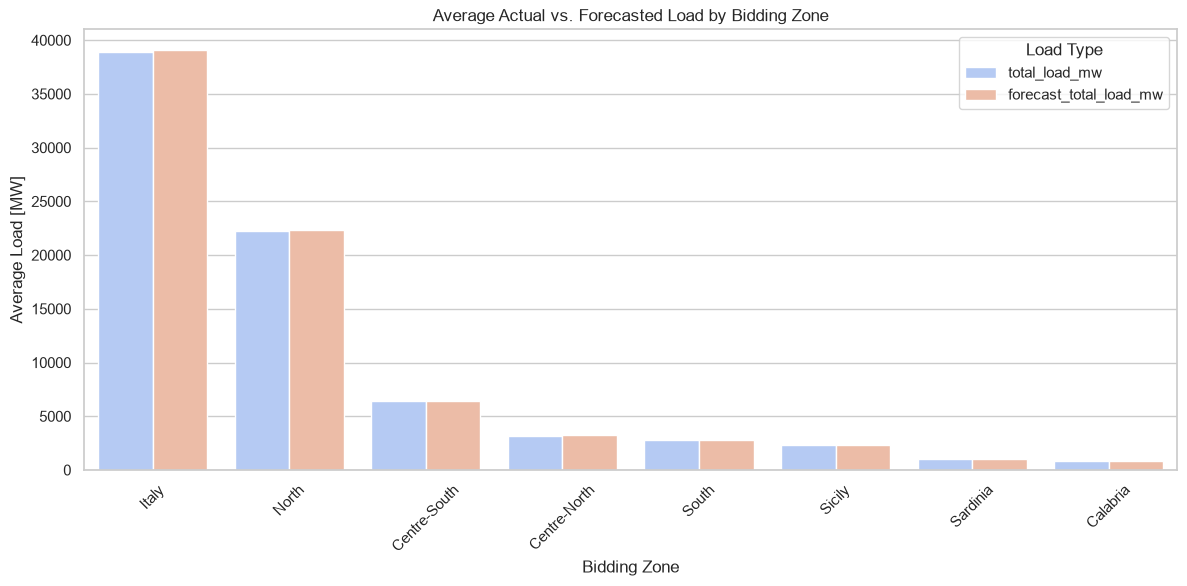

In [7]:
# Group by bidding zone and get average load
bidding_load = demand.groupby("bidding_zone")[["total_load_mw", "forecast_total_load_mw"]].mean().reset_index()
# Sort by actual load
bidding_load = bidding_load.sort_values(by="total_load_mw", ascending=False)

# Melt for side-by-side comparison plotting
melted_demand = bidding_load.melt(id_vars="bidding_zone", value_vars=["total_load_mw", "forecast_total_load_mw"], 
                                   var_name="Load Type", value_name="Load [MW]")

sns.barplot(data=melted_demand, x="bidding_zone", y="Load [MW]", hue="Load Type", palette="coolwarm")
plt.title("Average Actual vs. Forecasted Load by Bidding Zone")
plt.xlabel("Bidding Zone")
plt.ylabel("Average Load [MW]")
plt.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "06_actual_vs_forecast_demand.png"), dpi=150, bbox_inches="tight")
plt.show()


## 7. Electricity Generation by Primary Source


C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\1626268802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_gen, x="primary_source", y="actual_generation_mw", palette="summer")


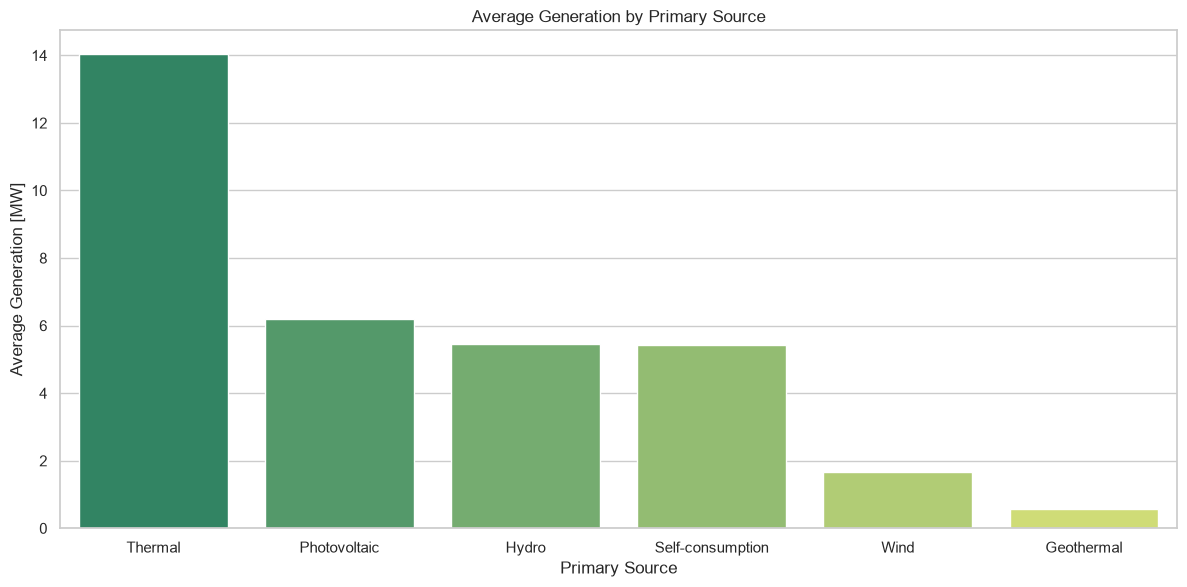

In [8]:
avg_gen = generation.groupby("primary_source")["actual_generation_mw"].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=avg_gen, x="primary_source", y="actual_generation_mw", palette="summer")
plt.title("Average Generation by Primary Source")
plt.xlabel("Primary Source")
plt.ylabel("Average Generation [MW]")

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "07_generation_by_source.png"), dpi=150, bbox_inches="tight")
plt.show()


## 8. Cross-border Imports/Exports Balance


C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\2989909220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_border, x="country", y="scheduled_foreign_exchange_mw", palette="vlag")


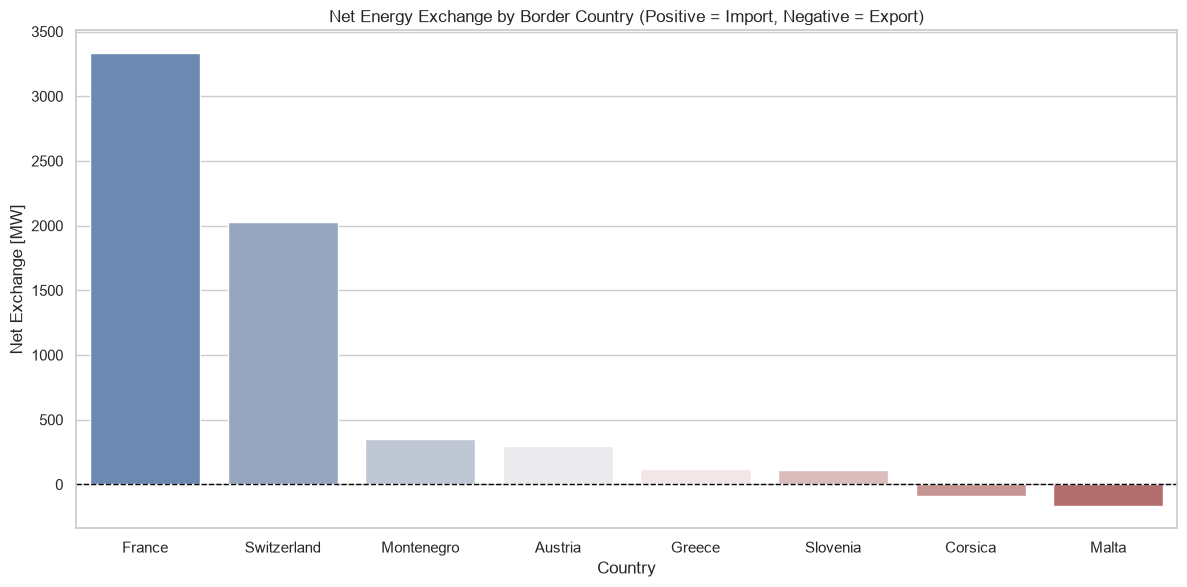

In [9]:
avg_border = imports.groupby("country")[["import_mw", "export_mw", "scheduled_foreign_exchange_mw"]].mean().reset_index()
avg_border = avg_border.sort_values(by="scheduled_foreign_exchange_mw", ascending=False)

# Plot net scheduled foreign exchange
sns.barplot(data=avg_border, x="country", y="scheduled_foreign_exchange_mw", palette="vlag")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Net Energy Exchange by Border Country (Positive = Import, Negative = Export)")
plt.xlabel("Country")
plt.ylabel("Net Exchange [MW]")

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "08_import_export_balances.png"), dpi=150, bbox_inches="tight")
plt.show()


## 9. Renewable Connection Requests by Region & Source


C:\Users\kk928\AppData\Local\Temp\ipykernel_57124\552428731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_regions, x="power_mw", y="region", palette="crest")


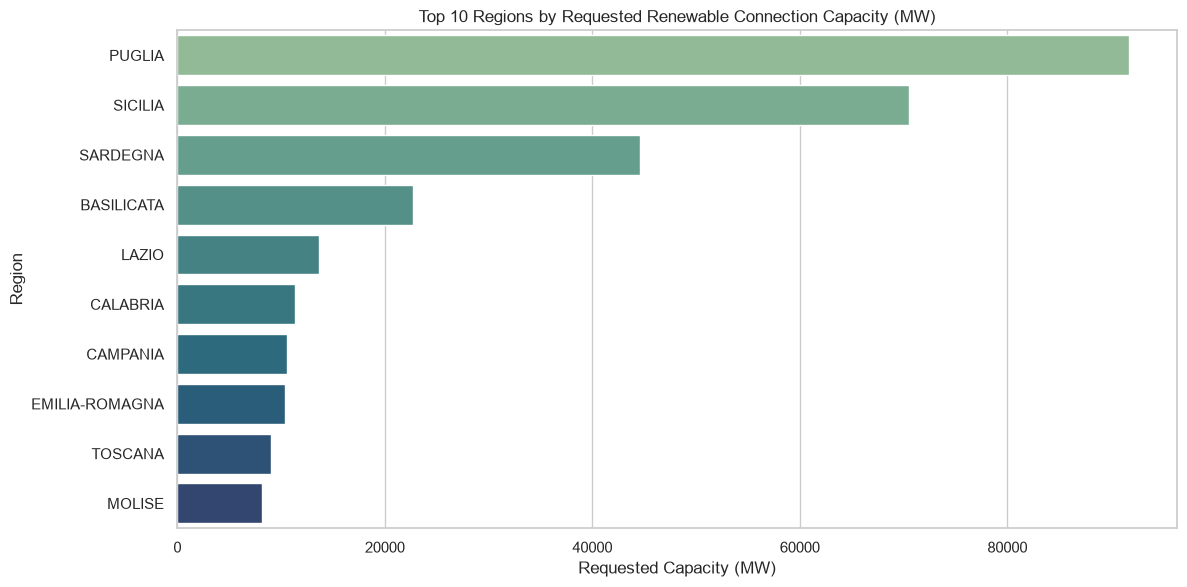

In [10]:
# Sum power (MW) by region
top_regions = requests.groupby("region")["power_mw"].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_regions, x="power_mw", y="region", palette="crest")
plt.title("Top 10 Regions by Requested Renewable Connection Capacity (MW)")
plt.xlabel("Requested Capacity (MW)")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "09_renewable_requests_by_region.png"), dpi=150, bbox_inches="tight")
plt.show()
